In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinothkannaece/sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/third/.cache/kagglehub/datasets/vinothkannaece/sales-dataset/versions/1


## 1. Load Data

In [22]:
import os
import pandas as pd

# The folder path printed by kagglehub
folder_path = "/home/third/.cache/kagglehub/datasets/vinothkannaece/sales-dataset/versions/1"

# Find all CSV files inside that folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

if csv_files:
    # Get the full path of the first CSV file found
    full_path = os.path.join(folder_path, csv_files[0])
    print(f"Loading file: {csv_files[0]}")
    
    # Load into pandas dataframe
    df = pd.read_csv(full_path)
    print(df.head())
else:
    print("No CSV files found in this directory. Here is what is inside:")
    print(os.listdir(folder_path))



Loading file: sales_data.csv
   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob

In [23]:
df.columns

Index(['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount',
       'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price',
       'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel',
       'Region_and_Sales_Rep'],
      dtype='object')

In [24]:
df.shape

(1000, 14)

In [25]:
print("================Product Category Counts=================")
df['Product_Category'].value_counts()

================Product Category Counts=================


Product_Category
Clothing       268
Furniture      260
Electronics    246
Food           226
Name: count, dtype: int64

In [26]:

print("================Region Counts=================")
df['Region'].value_counts()

================Region Counts=================


Region
North    267
East     263
West     244
South    226
Name: count, dtype: int64

In [27]:
df["Sales_Channel"].value_counts()

Sales_Channel
Retail    512
Online    488
Name: count, dtype: int64

In [28]:
df["Payment_Method"].value_counts()

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

In [29]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


<Axes: title={'center': 'Sales Amount Distribution'}, ylabel='Frequency'>

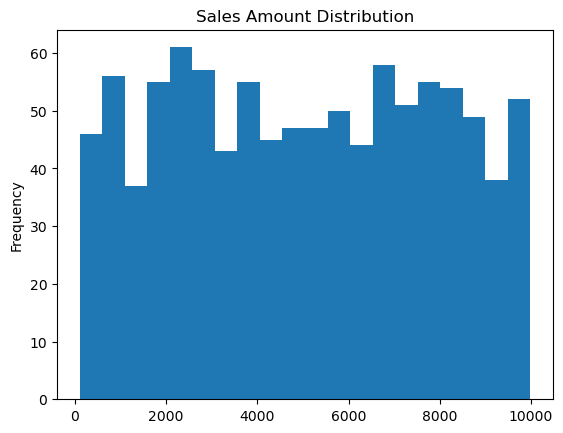

In [30]:
df['Sales_Amount'].plot(kind='hist', bins=20, title='Sales Amount Distribution')


<Axes: title={'center': 'Unit Price Spread'}>

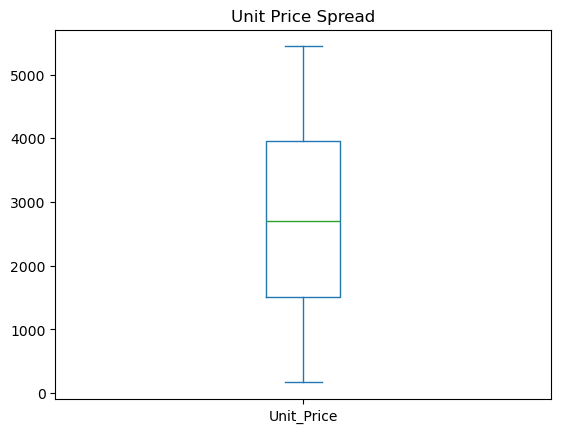

In [31]:
df['Unit_Price'].plot(kind='box', title='Unit Price Spread')


<Axes: title={'center': 'Quantity Sold Trend'}>

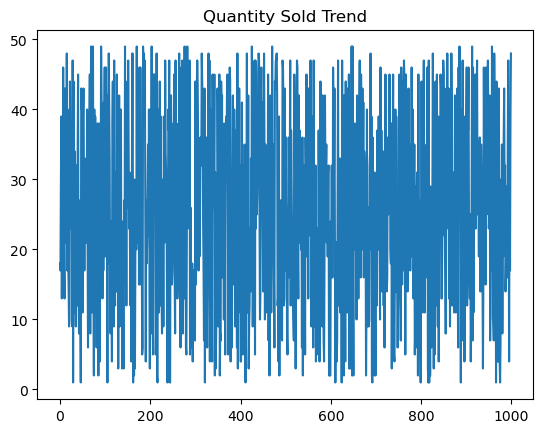

In [32]:
df['Quantity_Sold'].plot(kind='line', title='Quantity Sold Trend')


<Axes: title={'center': 'Cost vs. Price'}, xlabel='Unit_Cost', ylabel='Unit_Price'>

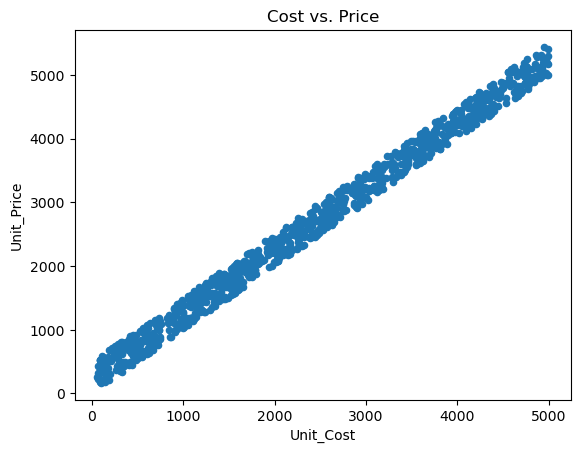

In [33]:
df.plot(kind='scatter', x='Unit_Cost', y='Unit_Price', title='Cost vs. Price')


Product_ID          Axes(0.125,0.53;0.227941x0.35)
Sales_Amount     Axes(0.398529,0.53;0.227941x0.35)
Quantity_Sold    Axes(0.672059,0.53;0.227941x0.35)
Unit_Cost           Axes(0.125,0.11;0.227941x0.35)
Unit_Price       Axes(0.398529,0.11;0.227941x0.35)
Discount         Axes(0.672059,0.11;0.227941x0.35)
dtype: object

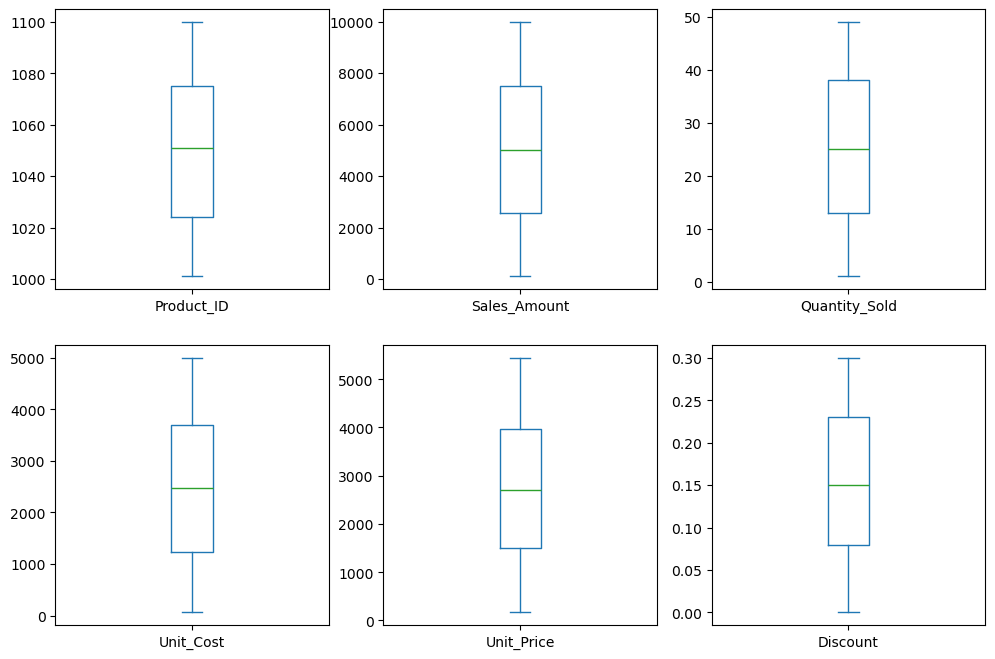

In [34]:
# Creates individual subplots for Sales_Amount, Quantity_Sold, etc.
df.plot(kind='box', subplots=True, layout=(2, 3), figsize=(12, 8))


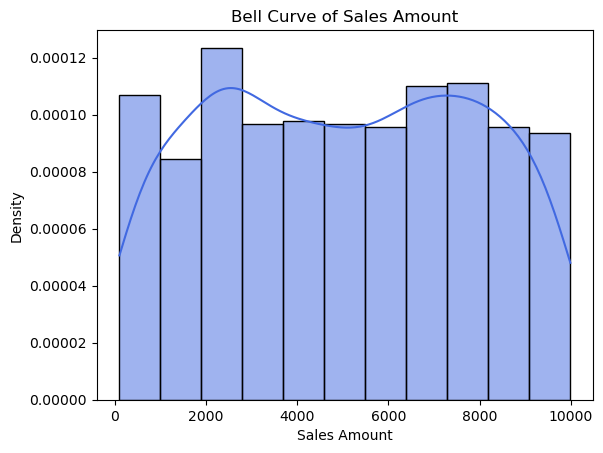

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Draws the histogram with a smooth bell curve line
sns.histplot(df["Sales_Amount"], kde=True, stat="density", color="royalblue")

plt.title("Bell Curve of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Density")
plt.show()


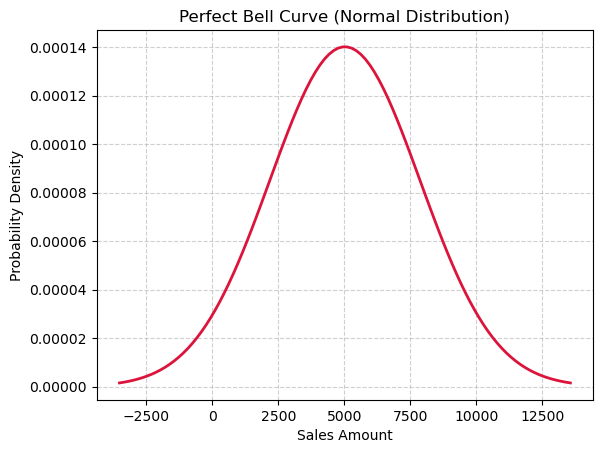

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# 1. Get mean and standard deviation from your data
# From your image: mean ≈ 5019.27, std ≈ 2846.79
mean = df["Sales_Amount"].mean()
std = df["Sales_Amount"].std()

# 2. Create an array of x-values ranging 3 standard deviations from the mean
x = np.linspace(mean - 3 * std, mean + 3 * std, 100)

# 3. Plot the normal distribution curve
plt.plot(x, stats.norm.pdf(x, mean, std), color="crimson", linewidth=2)

plt.title("Perfect Bell Curve (Normal Distribution)")
plt.xlabel("Sales Amount")
plt.ylabel("Probability Density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [37]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

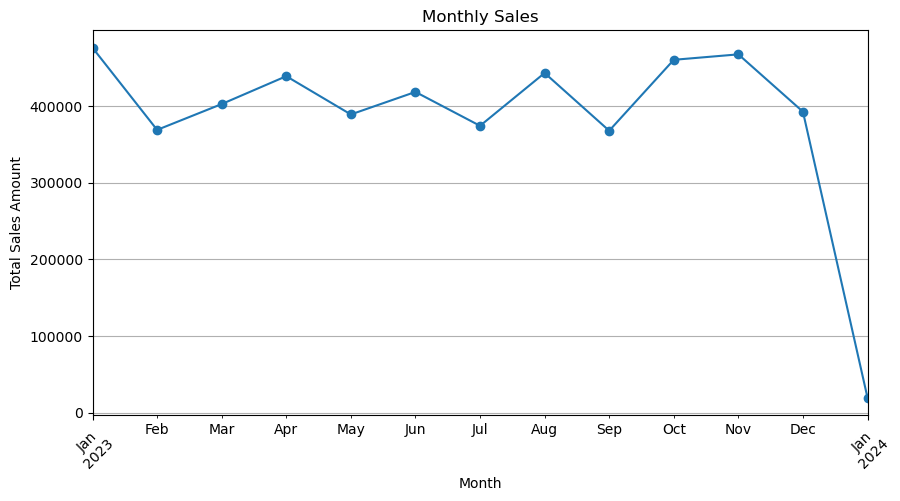

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Sale_Date to datetime
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

# Group by month
monthly_sales = df.groupby(df["Sale_Date"].dt.to_period("M"))["Sales_Amount"].sum()

# Plot
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()